In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import math as m

In [ ]:
import tqdm
import kagglehub, os

In [ ]:
key = "energy_consumption"

FILE = "tetuan-city-power-consumption"

path = kagglehub.dataset_download(f"gmkeshav/{FILE}")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Downloaded files:", files)
df = pd.read_csv(os.path.join(path, files[0]))
df.info()

# store files locally
# df.to_parquet(f'{FILE}.parquet')

In [ ]:
# t_1, ..., t_S

# Set the period
period = 144    # S / L

L = 40

instances = period*L    # S = 144 * L

column = 'Zone 1 Power Consumption'

# Read from stored files
# df = pd.read_parquet(f'{FILE}.parquet')

dates_energy = df["DateTime"].values[0:instances]

energy_consumption = df[column].values[0:instances]

In [ ]:
if key == "energy_consumption":
    ts = energy_consumption
    dates = dates_energy

In [ ]:
#requires "pip install -e ." from root directory

import sw1pers_l
from sw1pers_l.core import SW1PerS, SW1PerS_L

In [ ]:
scores = SW1PerS_L(ts, rolling_size=3, factor = 2, choose_hyper_param=True)

# algorithm comparison

In [ ]:
from sw1pers_l.time_series.sliding_windows import make_sliding_windows

In [80]:
from sw1pers_l.sw1pers_scores.plot import plot_scores_comparison
from sw1pers_l.sw1pers_scores.plot import plot_score_landscape

In [ ]:
window_size = len(ts)//38
window_stride = window_size//4
rolling_size_scores = window_size//window_stride

ts_windows = make_sliding_windows(ts.reshape(len(ts), ), window_size, window_stride)

freqs = np.linspace(1/window_size, 1/(window_size*0.6), 100)    # create an array of frequencies to be tested

## JTK

In [ ]:
from scipy.stats import kendalltau    # import ingredient for JTK algorithm

In [ ]:
def jtk_cycle_score(x, time=None, periods=np.arange(16, 36), n_phases=24):
    x = np.asarray(x)

    if time is None:
        time = np.arange(len(x))
    else:
        time = np.asarray(time)

    best_score = -np.inf     # compare abs(tau)
    best_tau = None
    best_period = None
    best_phase = None

    for P in periods:
        phases = np.linspace(0, P, n_phases, endpoint=False)

        for phi in phases:
            ref = np.cos((2*np.pi/P) * (time - phi))

            tau, _ = kendalltau(x, ref, nan_policy='omit')

            # Skip invalid tau
            if tau is None or np.isnan(tau):
                continue

            score = np.abs(tau)
            if score > best_score:
                best_score = score
                best_tau = tau
                best_period = P
                best_phase = phi

    return best_tau, best_period, best_phase

In [ ]:
jtk_scores=[]

for i, window in enumerate(ts_windows):
    y_axis = window
    x_axis = np.arange(len(window))
    tau, _, _ = jtk_cycle_score(y_axis, x_axis, periods = np.arange(int(window_size*0.6), int(window_size*1)), n_phases=2)   # evaluate 2 phases, can increase
    jtk_scores.append(tau)

In [ ]:
plot_scores_comparison(scores, jtk_scores[:len(scores)], window_size, window_stride, dates)

## Lomb-Scargle

In [ ]:
#pip install astropy

In [ ]:
from astropy.timeseries import LombScargle    # import lomb-scargle

In [ ]:
lomb_scargle_scores=[]

for i, window in enumerate(ts_windows):
    y_axis = window
    x_axis = np.arange(len(window))
    power = LombScargle(x_axis, y_axis).power(freqs)
    lomb_scargle_scores.append(np.max(power))

In [ ]:
len(lomb_scargle_scores), len(scores)

In [ ]:
plot_scores_comparison(scores, lomb_scargle_scores[:len(scores)], window_size, window_stride, dates)

## LOF (local outlier factor)

In [ ]:
from pyod.models.lof import LOF

In [ ]:
def run_lof(ts, window_size=24, n_neighbors=20):
    X = make_sliding_windows(ts, window_size, window_stride)

    clf = LOF(
        n_neighbors=n_neighbors,
        contamination=0.05
    )

    clf.fit(X)

    scores = clf.decision_scores_

    # map back to timeline
    ts_scores = np.zeros(len(ts))
    ts_scores[window_size - 1::window_stride] = scores

    return ts_scores

In [ ]:
#compute LOF scores
lof_scores = run_lof(ts, window_size=window_size)   # needs sliding_windows function

#filter out zeros
nonzero_lof_scores=[]
for num in lof_scores:
    if num>0.1:
        nonzero_lof_scores.append(num)

In [84]:
from sw1pers_l.sw1pers_scores._density import density

In [ ]:
score_lof_arr = []
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

step = len(ts)/len(nonzero_lof_scores)
x_axis = np.arange(window_size, len(ts), window_stride)

ax1.plot(x_axis, density(scores, 10), color = "red")
ax1.set_ylabel("Periodicity Score", color = 'orange')
ax1.tick_params(axis='y', labelcolor = 'orange')

ax2.plot(x_axis, nonzero_lof_scores, label="LOF score", alpha=0.6)
ax2.set_ylabel("LOF score", color = "C0")
ax2.tick_params(axis='y', labelcolor = "C0")

In [ ]:
# standard --> rolling_size_scores = window_size/window_stride

plot_scores_comparison(density(scores, 10), nonzero_lof_scores, window_size, window_stride, dates, rolling_size_scores=10)

## Isolation Forest

In [ ]:
import pyod

In [66]:
from pyod.models.iforest import IForest
from sw1pers_l.windows.make_emb_ts import make_embedded_ts

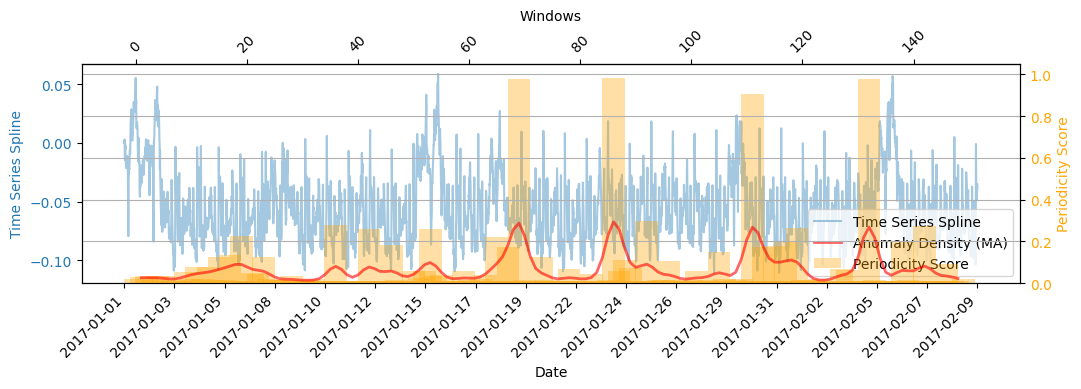

In [88]:
emb_ts, _, _ = make_embedded_ts(ts)

clf = IForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

clf.fit(emb_ts)

scores_isolation = clf.decision_scores_

plot_score_landscape(scores, density(scores, 12), scores_isolation, window_size, window_stride, dates, 2)